COMMENT VOLUME & SCORE vs. bat_score SEVERITY
Posts (bat_score>0): 12,237
Posts with ZERO surviving top-level comments: 452 (3.7%)
(These are included with comment_count=0 — dropping them would bias the volume trend upward.)

────────────────────────────────────────────────────────────
COMMENT VOLUME by bat_score
────────────────────────────────────────────────────────────
           count   mean  median    std
bat_score                             
1           7232  22.29     7.0  45.07
2           3043  25.74     9.0  48.03
3           1573  28.68    11.0  49.34
4            389  30.33    11.0  54.40

────────────────────────────────────────────────────────────
MEAN COMMENT SCORE by bat_score (posts with >=1 comment only)
────────────────────────────────────────────────────────────
           count  mean  median   std
bat_score                           
1           6942  5.43    3.67  5.27
2           2941  5.86    4.17  5.23
3           1528  6.26    4.80  5.86
4            374  5.

/Users/nadia/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "



✓ Figure saved: /Users/nadia/Desktop/redditRun_june/comment_data/volume_score_by_batscore.png

✓ volume_score_by_batscore_summary.csv saved  →  12,237 posts


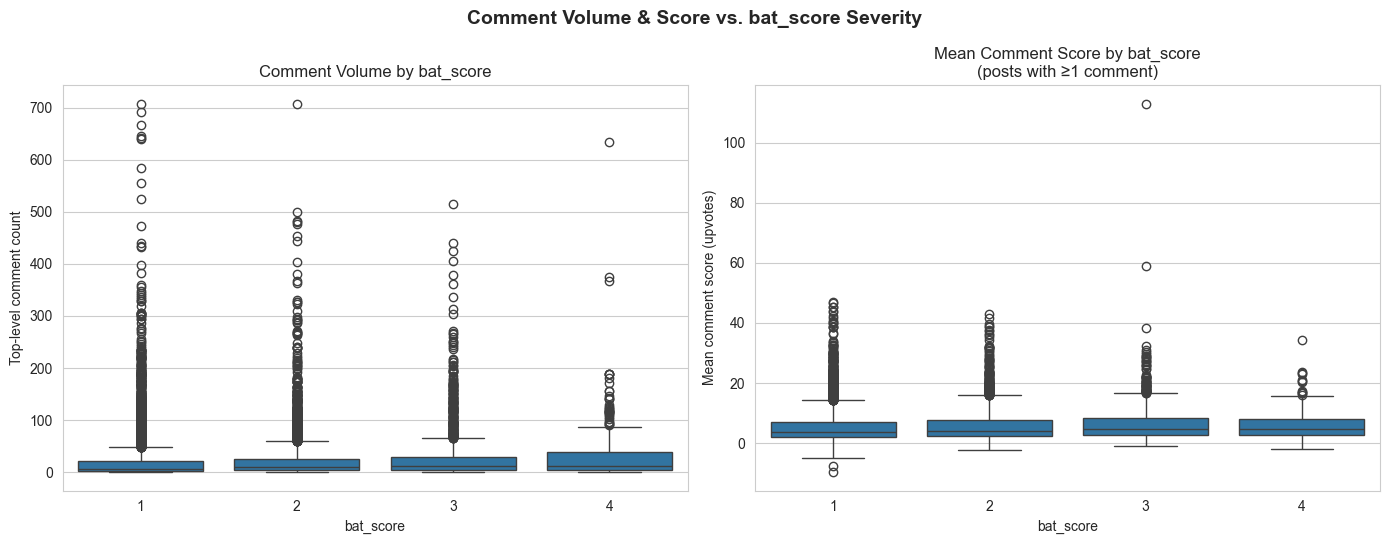

In [1]:
"""
ANALYSIS: COMMENT VOLUME & SCORE vs. bat_score SEVERITY
===========================================================
Question: does comment volume (top-level comments per post) or mean
comment score (upvotes) go DOWN as bat_score (1-4) goes up?

Scope note: master_comments_filtered.csv only has comments for
bat_score>0 posts. This tests the trend WITHIN 1-4, not against a
bat_score=0 baseline. If "burnout posts get less engagement than
non-burnout posts" matters for the paper, that needs a separate
bat_score=0 comparison sample pulled later.

Reads:
    master_comments_filtered.csv
    bat_score_pos.csv

Writes:
    volume_score_by_batscore_summary.csv
    volume_score_by_batscore.png

Install once:
    pip install pandas numpy scipy statsmodels matplotlib seaborn --break-system-packages
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR = '/Users/nadia/Desktop/redditRun_june/comment_data/'
COMMENTS_FILE = DATA_DIR + 'master_comments_filtered.csv'
BAT_FILE = DATA_DIR + 'bat_score_pos.csv'
OUTPUT_DIR = DATA_DIR

sns.set_style("whitegrid")


# ── STEP 1: BUILD POST-LEVEL TABLE ──────────────────────────────────────────
def build_post_level_table():
    comments = pd.read_csv(COMMENTS_FILE)
    bat = pd.read_csv(BAT_FILE, usecols=['post_id', 'bat_score'])

    comments['post_id'] = comments['post_id'].astype(str)
    bat['post_id'] = bat['post_id'].astype(str)

    # comment volume + mean/median score per post
    agg = comments.groupby('post_id').agg(
        comment_count=('id', 'count'),
        mean_comment_score=('score', 'mean'),
        median_comment_score=('score', 'median'),
        total_comment_score=('score', 'sum'),
    ).reset_index()

    # LEFT join from bat (all bat_score>0 posts), so posts with ZERO
    # surviving top-level comments show up as comment_count=0, not missing.
    # This matters: if we only used comments.groupby, posts with no comments
    # would silently disappear, biasing the volume analysis upward.
    post_level = bat.merge(agg, on='post_id', how='left')
    post_level['comment_count'] = post_level['comment_count'].fillna(0).astype(int)

    n_zero = (post_level['comment_count'] == 0).sum()
    print(f"Posts (bat_score>0): {len(post_level):,}")
    print(f"Posts with ZERO surviving top-level comments: {n_zero:,} "
          f"({n_zero/len(post_level)*100:.1f}%)")
    print("(These are included with comment_count=0 — dropping them would "
          "bias the volume trend upward.)")

    return post_level


# ── STEP 2: DESCRIPTIVES BY bat_score ───────────────────────────────────────
def descriptives_by_batscore(post_level):
    print("\n" + "─" * 60)
    print("COMMENT VOLUME by bat_score")
    print("─" * 60)
    print(post_level.groupby('bat_score')['comment_count']
          .agg(['count', 'mean', 'median', 'std']).round(2))

    print("\n" + "─" * 60)
    print("MEAN COMMENT SCORE by bat_score (posts with >=1 comment only)")
    print("─" * 60)
    with_comments = post_level[post_level['comment_count'] > 0]
    print(with_comments.groupby('bat_score')['mean_comment_score']
          .agg(['count', 'mean', 'median', 'std']).round(2))

    return with_comments


# ── STEP 3: TREND TESTS ─────────────────────────────────────────────────────
def trend_tests(post_level, with_comments):
    print("\n" + "─" * 60)
    print("TREND TESTS")
    print("─" * 60)

    # --- Volume: Spearman (ordinal bat_score vs count) ---
    rho, p = stats.spearmanr(post_level['bat_score'], post_level['comment_count'])
    print(f"\nSpearman (bat_score vs comment_count): rho={rho:.4f}, p={p:.4g}")

    # --- Volume: Kruskal-Wallis across the 4 groups ---
    groups = [post_level.loc[post_level['bat_score'] == s, 'comment_count']
              for s in sorted(post_level['bat_score'].unique())]
    h, p_kw = stats.kruskal(*groups)
    print(f"Kruskal-Wallis (comment_count across bat_score groups): H={h:.3f}, p={p_kw:.4g}")

    # --- Score: Spearman ---
    rho_s, p_s = stats.spearmanr(with_comments['bat_score'], with_comments['mean_comment_score'])
    print(f"\nSpearman (bat_score vs mean_comment_score): rho={rho_s:.4f}, p={p_s:.4g}")

    # --- Score: Kruskal-Wallis ---
    groups_s = [with_comments.loc[with_comments['bat_score'] == s, 'mean_comment_score']
                for s in sorted(with_comments['bat_score'].unique())]
    h_s, p_kw_s = stats.kruskal(*groups_s)
    print(f"Kruskal-Wallis (mean_comment_score across bat_score groups): H={h_s:.3f}, p={p_kw_s:.4g}")


# ── STEP 4: REGRESSION MODELS ───────────────────────────────────────────────
def regression_models(post_level, with_comments):
    print("\n" + "─" * 60)
    print("REGRESSION: comment_count ~ bat_score")
    print("─" * 60)

    # Check overdispersion to decide Poisson vs Negative Binomial
    mean_cc = post_level['comment_count'].mean()
    var_cc = post_level['comment_count'].var()
    print(f"Mean={mean_cc:.2f}, Variance={var_cc:.2f}, "
          f"Variance/Mean ratio={var_cc/mean_cc:.2f}")
    print("(Ratio >> 1 indicates overdispersion → Negative Binomial preferred over Poisson)")

    if var_cc / mean_cc > 1.5:
        print("\nFitting Negative Binomial GLM (overdispersion detected)...")
        nb_model = smf.glm('comment_count ~ bat_score', data=post_level,
                            family=sm.families.NegativeBinomial()).fit()
        print(nb_model.summary())
    else:
        print("\nFitting Poisson GLM...")
        poisson_model = smf.glm('comment_count ~ bat_score', data=post_level,
                                 family=sm.families.Poisson()).fit()
        print(poisson_model.summary())

    print("\n" + "─" * 60)
    print("REGRESSION: mean_comment_score ~ bat_score  (OLS, posts with >=1 comment)")
    print("─" * 60)
    ols_model = smf.ols('mean_comment_score ~ bat_score', data=with_comments).fit()
    print(ols_model.summary())


# ── STEP 5: VISUALIZATION ───────────────────────────────────────────────────
def make_figure(post_level, with_comments):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle('Comment Volume & Score vs. bat_score Severity', fontsize=14, fontweight='bold')

    sns.boxplot(data=post_level, x='bat_score', y='comment_count', ax=axes[0])
    axes[0].set_title('Comment Volume by bat_score')
    axes[0].set_ylabel('Top-level comment count')

    sns.boxplot(data=with_comments, x='bat_score', y='mean_comment_score', ax=axes[1])
    axes[1].set_title('Mean Comment Score by bat_score\n(posts with ≥1 comment)')
    axes[1].set_ylabel('Mean comment score (upvotes)')

    plt.tight_layout()
    out_path = OUTPUT_DIR + 'volume_score_by_batscore.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"\n✓ Figure saved: {out_path}")


# ── MAIN ─────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    print("=" * 80)
    print("COMMENT VOLUME & SCORE vs. bat_score SEVERITY")
    print("=" * 80)

    post_level = build_post_level_table()
    with_comments = descriptives_by_batscore(post_level)
    trend_tests(post_level, with_comments)
    regression_models(post_level, with_comments)
    make_figure(post_level, with_comments)

    post_level.to_csv(OUTPUT_DIR + 'volume_score_by_batscore_summary.csv', index=False)
    print(f"\n✓ volume_score_by_batscore_summary.csv saved  →  {len(post_level):,} posts")

In [2]:
comments = pd.read_csv(COMMENTS_FILE)
bat = pd.read_csv(BAT_FILE, usecols=['post_id', 'bat_score'])

print("bat post_id sample:", bat['post_id'].astype(str).head(5).tolist())
print("comments post_id sample:", comments['post_id'].astype(str).head(5).tolist())

print("bat post_id duplicated?", bat['post_id'].duplicated().sum())
print("bat unique posts:", bat['post_id'].nunique(), "vs rows:", len(bat))

matched = bat['post_id'].astype(str).isin(comments['post_id'].astype(str))
print(f"bat posts with ANY matching comment post_id: {matched.sum():,} / {len(bat):,}")

bat post_id sample: ['12t87xb', '1epl8ed', '1fbh2gy', '1k7d8py', '1mzmorn']
comments post_id sample: ['12t87xb', '12t87xb', '12t87xb', '12t87xb', '1epl8ed']
bat post_id duplicated? 0
bat unique posts: 12237 vs rows: 12237
bat posts with ANY matching comment post_id: 11,785 / 12,237
